In [1]:
# =============================================================
# GSE2034 Complete Bioinformatics Analysis
# Breast Cancer Bone Relapse — Gene Expression Profiling
# Author: Luis Angel Carmona | Biological Engineer | Bioinformatics + AI
# Dataset: Wang et al. 2005, The Lancet
# =============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.stats.multitest import multipletests
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import gzip
import os
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 150
plt.rcParams['font.size'] = 11

print('=== GSE2034 Complete Analysis ===')
print('All libraries loaded successfully')

=== GSE2034 Complete Analysis ===
All libraries loaded successfully


In [2]:
# ── LOAD DATA ──────────────────────────────────────────────
expr = pd.read_csv('expresion_filtrada.csv', index_col=0)
meta = pd.read_csv('metadata_clinica.csv')

# Extract bone relapse label
meta['bone_relapse'] = meta['characteristics_ch1'].str.extract(
    r'bone relapses \(1=yes, 0=no\): (\d)'
).astype(float)

# Transpose for sklearn: patients in rows, genes in columns
X = expr.T
muestras = [s for s in X.index if s in meta['sample_id'].values]
X = X.loc[muestras]
meta_al = meta.set_index('sample_id').loc[muestras].reset_index()
etiquetas = meta_al['bone_relapse'].values

# Separate groups for DEG analysis
grupo_relapse    = [s for s in muestras if meta_al.set_index('sample_id').loc[s, 'bone_relapse'] == 1]
grupo_no_relapse = [s for s in muestras if meta_al.set_index('sample_id').loc[s, 'bone_relapse'] == 0]
expr_relapse    = expr[grupo_relapse]
expr_no_relapse = expr[grupo_no_relapse]

print('=== Dataset Summary ===')
print(f'Total patients:      {X.shape[0]}')
print(f'Genes (filtered):    {X.shape[1]:,}')
print(f'Bone relapse (1):    {int(etiquetas.sum())}')
print(f'No relapse (0):      {int((etiquetas==0).sum())}')
print(f'Relapse rate:        {etiquetas.mean()*100:.1f}%')

=== Dataset Summary ===
Total patients:      286
Genes (filtered):    16,712
Bone relapse (1):    69
No relapse (0):      217
Relapse rate:        24.1%


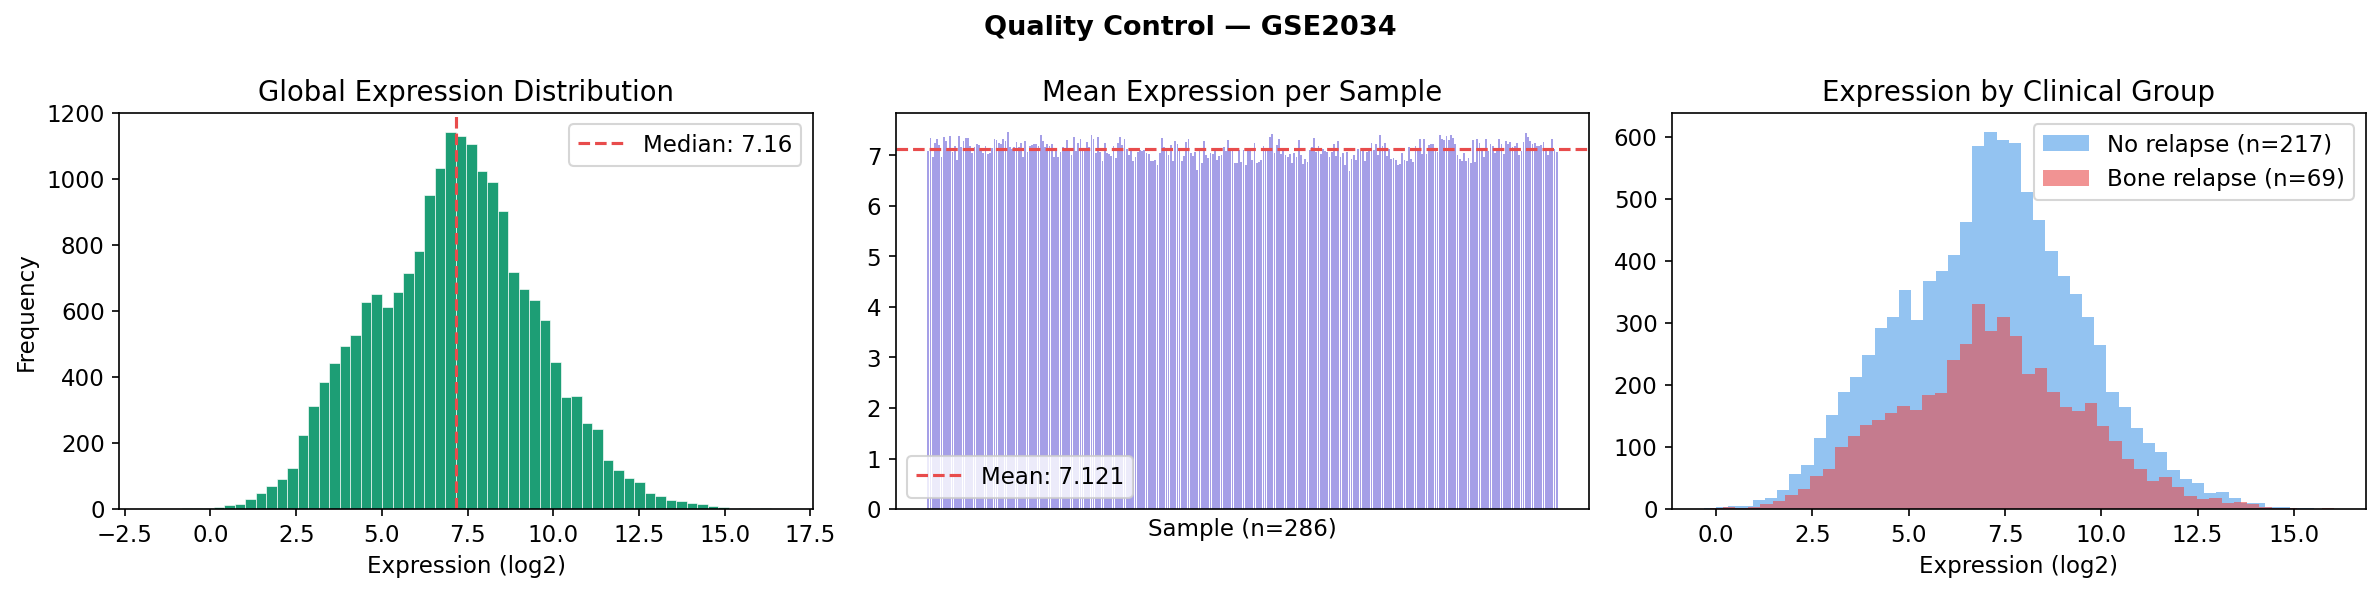

Saved: final_qc_panel.png


In [3]:
# ── QUALITY CONTROL PANEL ──────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# 1. Distribución global
vals = expr.values.flatten()
vals = vals[~np.isnan(vals)]
muestra_vals = np.random.choice(vals, size=20000, replace=False)

axes[0].hist(muestra_vals, bins=60, color='#1D9E75',
             edgecolor='white', linewidth=0.3)
axes[0].axvline(np.median(muestra_vals), color='#E84C4C',
                linestyle='--', label=f'Median: {np.median(muestra_vals):.2f}')
axes[0].set_title('Global Expression Distribution')
axes[0].set_xlabel('Expression (log2)')
axes[0].set_ylabel('Frequency')
axes[0].legend()

# 2. Media por muestra
medias_m = expr.mean(axis=0)
axes[1].bar(range(len(medias_m)), medias_m.values,
            color='#7F77DD', alpha=0.7)
axes[1].axhline(medias_m.mean(), color='#E84C4C',
                linestyle='--', label=f'Mean: {medias_m.mean():.3f}')
axes[1].set_title('Mean Expression per Sample')
axes[1].set_xlabel(f'Sample (n={len(medias_m)})')
axes[1].set_xticks([])
axes[1].legend()

# 3. Distribución por grupo clínico
data_relapse    = expr[grupo_relapse].values.flatten()
data_no_relapse = expr[grupo_no_relapse].values.flatten()
data_relapse    = data_relapse[~np.isnan(data_relapse)]
data_no_relapse = data_no_relapse[~np.isnan(data_no_relapse)]

axes[2].hist(np.random.choice(data_no_relapse, 10000), bins=50,
             alpha=0.6, color='#4C9BE8', label=f'No relapse (n={len(grupo_no_relapse)})')
axes[2].hist(np.random.choice(data_relapse, 5000), bins=50,
             alpha=0.6, color='#E84C4C', label=f'Bone relapse (n={len(grupo_relapse)})')
axes[2].set_title('Expression by Clinical Group')
axes[2].set_xlabel('Expression (log2)')
axes[2].legend()

plt.suptitle('Quality Control — GSE2034', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('final_qc_panel.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: final_qc_panel.png')

In [4]:
# ── DIFFERENTIAL EXPRESSION ANALYSIS ──────────────────────
print('Running differential expression analysis...')
print(f'Testing {len(expr):,} genes...')

resultados = []
for gen in expr.index:
    vals_r  = expr_relapse.loc[gen].dropna().values
    vals_nr = expr_no_relapse.loc[gen].dropna().values
    if len(vals_r) < 3 or len(vals_nr) < 3:
        continue
    _, p_val = stats.ttest_ind(vals_r, vals_nr)
    resultados.append({
        'gene':           gen,
        'mean_relapse':   round(vals_r.mean(), 4),
        'mean_no_relapse':round(vals_nr.mean(), 4),
        'log2FC':         round(vals_r.mean() - vals_nr.mean(), 4),
        'p_value':        p_val
    })

df_deg = pd.DataFrame(resultados)
_, fdr, _, _ = multipletests(df_deg['p_value'].values, method='fdr_bh')
df_deg['FDR'] = fdr
df_deg = df_deg.sort_values('FDR')

# Filter significant DEGs
degs = df_deg[(df_deg['FDR'] < 0.05) & (df_deg['log2FC'].abs() > 1)].copy()
degs_up   = degs[degs['log2FC'] >  1]
degs_down = degs[degs['log2FC'] < -1]

print(f'Analysis complete: {len(df_deg):,} genes tested')
print()
print('=== Differentially Expressed Genes ===')
print(f'Total DEGs:     {len(degs)}')
print(f'Upregulated:    {len(degs_up)}  (more active in bone relapse)')
print(f'Downregulated:  {len(degs_down)} (less active in bone relapse)')
print(f'Most significant: {degs.iloc[0]["gene"]} (FDR={degs.iloc[0]["FDR"]:.6f})')

Running differential expression analysis...
Testing 16,712 genes...
Analysis complete: 16,712 genes tested

=== Differentially Expressed Genes ===
Total DEGs:     35
Upregulated:    7  (more active in bone relapse)
Downregulated:  28 (less active in bone relapse)
Most significant: 214777_at (FDR=0.005330)


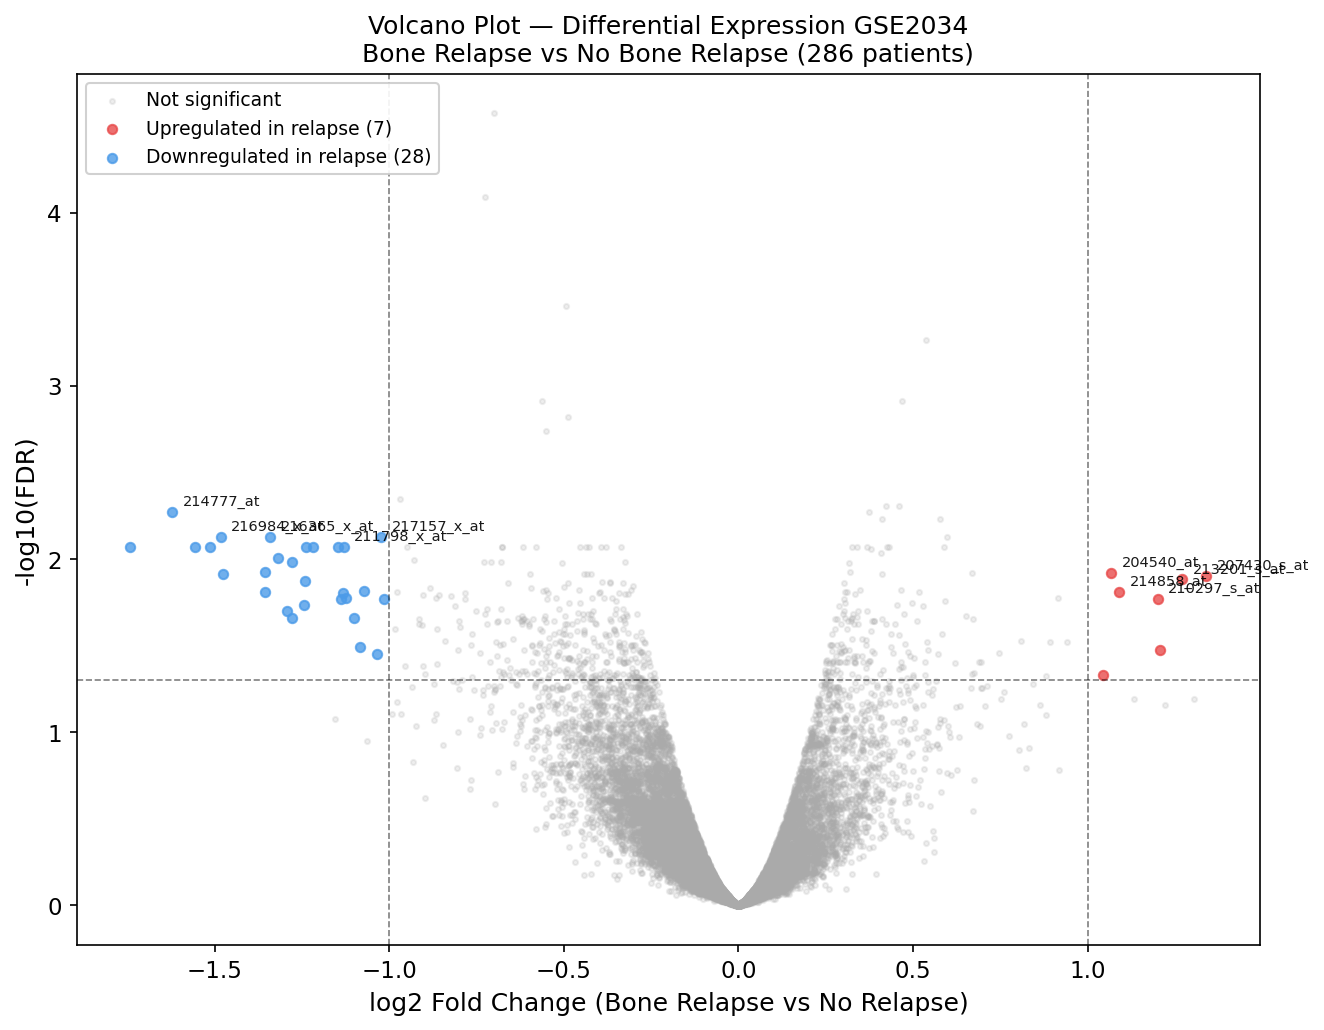

Saved: final_volcano.png


In [5]:
# ── VOLCANO PLOT ───────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 7))

df_deg['neg_log10_FDR'] = -np.log10(df_deg['FDR'].clip(lower=1e-300))

no_sig   = df_deg[(df_deg['FDR'] >= 0.05) | (df_deg['log2FC'].abs() <= 1)]
sig_up   = df_deg[(df_deg['FDR'] < 0.05) & (df_deg['log2FC'] >  1)]
sig_down = df_deg[(df_deg['FDR'] < 0.05) & (df_deg['log2FC'] < -1)]

ax.scatter(no_sig['log2FC'],   no_sig['neg_log10_FDR'],
           alpha=0.2, s=6, color='#AAAAAA', label='Not significant')
ax.scatter(sig_up['log2FC'],   sig_up['neg_log10_FDR'],
           alpha=0.8, s=20, color='#E84C4C',
           label=f'Upregulated in relapse ({len(sig_up)})')
ax.scatter(sig_down['log2FC'], sig_down['neg_log10_FDR'],
           alpha=0.8, s=20, color='#4C9BE8',
           label=f'Downregulated in relapse ({len(sig_down)})')

ax.axhline(-np.log10(0.05), color='black',
           linestyle='--', linewidth=0.8, alpha=0.5)
ax.axvline( 1, color='black', linestyle='--', linewidth=0.8, alpha=0.5)
ax.axvline(-1, color='black', linestyle='--', linewidth=0.8, alpha=0.5)

# Etiquetar top 5 de cada grupo
top = pd.concat([sig_up.head(5), sig_down.head(5)])
for _, row in top.iterrows():
    ax.annotate(row['gene'],
                xy=(row['log2FC'], row['neg_log10_FDR']),
                xytext=(5, 3), textcoords='offset points',
                fontsize=7, alpha=0.9)

ax.set_xlabel('log2 Fold Change (Bone Relapse vs No Relapse)', fontsize=12)
ax.set_ylabel('-log10(FDR)', fontsize=12)
ax.set_title('Volcano Plot — Differential Expression GSE2034\n'
             'Bone Relapse vs No Bone Relapse (286 patients)',
             fontsize=12)
ax.legend(loc='upper left', framealpha=0.9, fontsize=9)

plt.tight_layout()
plt.savefig('final_volcano.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: final_volcano.png')

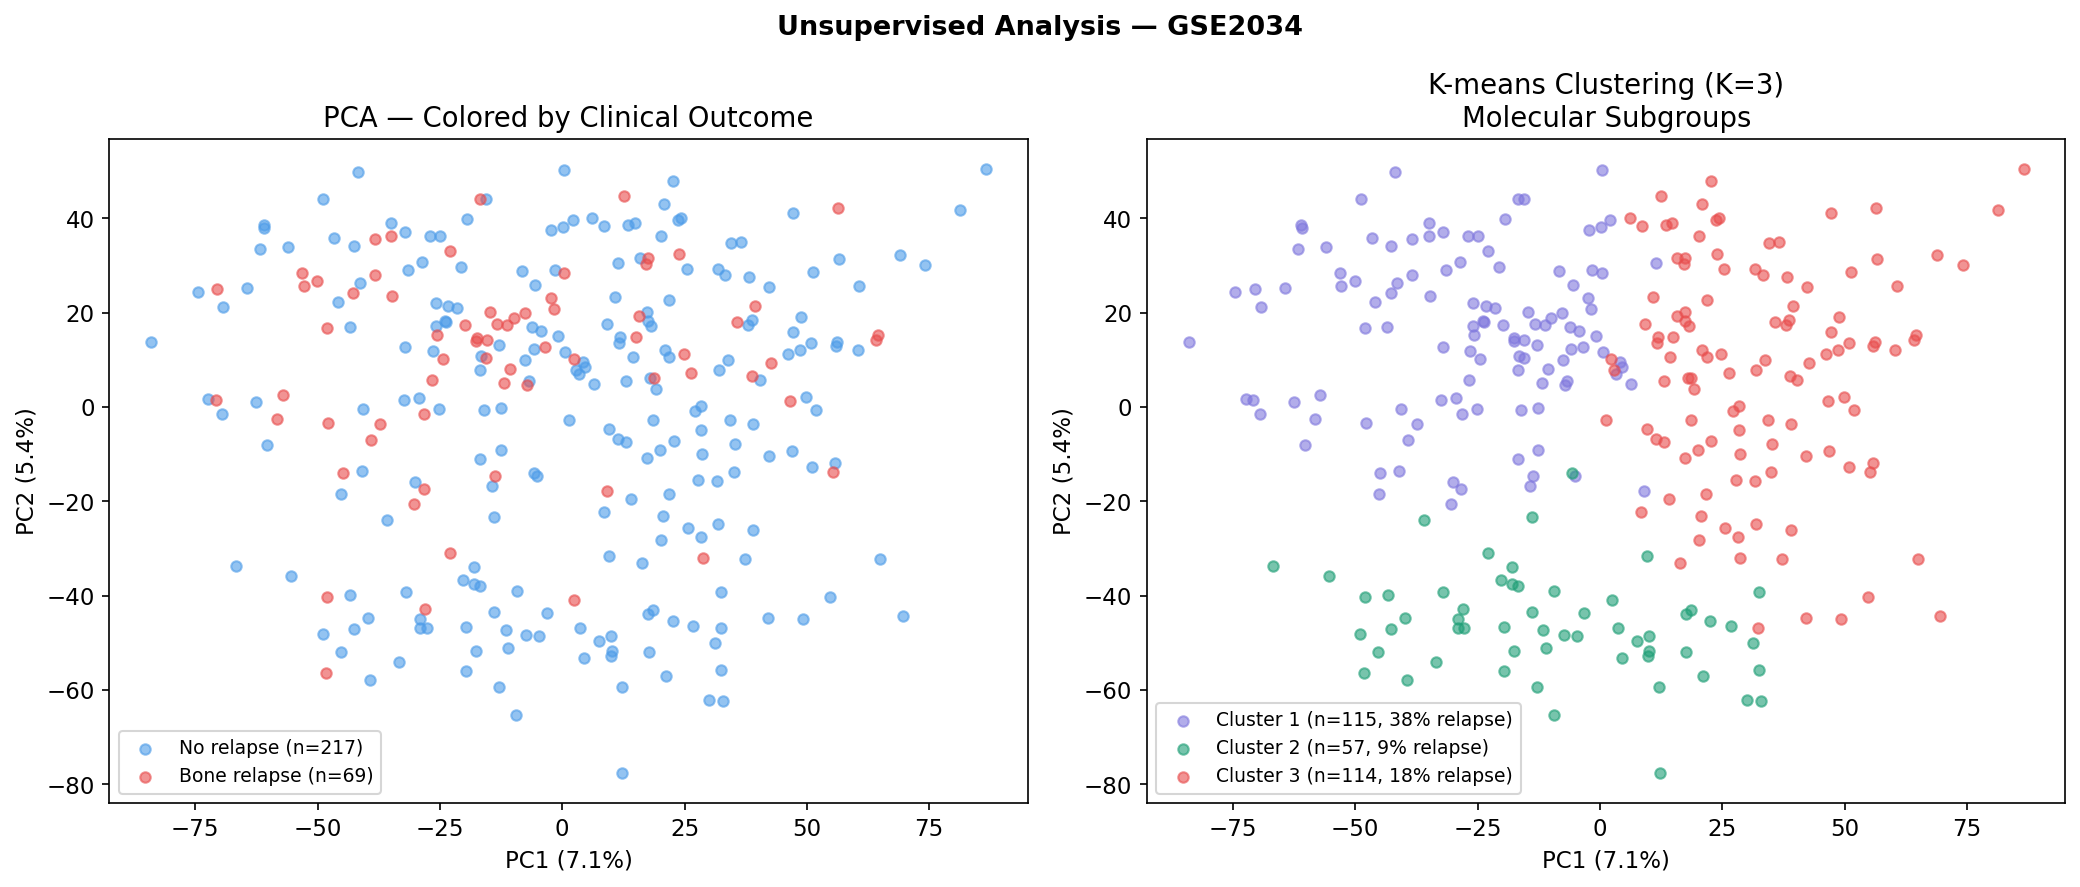

Saved: final_pca_clustering.png

=== Clustering Results ===
Cluster 1 (n=115): 44 relapses (38.3%) — HIGH RISK
Cluster 2 (n=57): 5 relapses (8.8%) — LOW RISK
Cluster 3 (n=114): 20 relapses (17.5%) — INTERMEDIATE


In [6]:
# ── PCA AND CLUSTERING PANEL ───────────────────────────────
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=50, random_state=42)
X_pca = pca.fit_transform(X_scaled)
varianza = pca.explained_variance_ratio_

X_cl = X_pca[:, :10]
km = KMeans(n_clusters=3, random_state=42, n_init=10)
cluster_labels = km.fit_predict(X_cl)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Izquierda: PCA coloreado por recaída clínica
colores_r = {1.0: '#E84C4C', 0.0: '#4C9BE8'}
for grupo in [0.0, 1.0]:
    mask = etiquetas == grupo
    axes[0].scatter(X_pca[mask, 0], X_pca[mask, 1],
                    c=colores_r[grupo], alpha=0.6, s=25,
                    label=f'{"Bone relapse" if grupo==1 else "No relapse"} (n={mask.sum()})')
axes[0].set_xlabel(f'PC1 ({varianza[0]*100:.1f}%)', fontsize=11)
axes[0].set_ylabel(f'PC2 ({varianza[1]*100:.1f}%)', fontsize=11)
axes[0].set_title('PCA — Colored by Clinical Outcome')
axes[0].legend(fontsize=9)

# Derecha: clustering molecular
colores_c = {0: '#7F77DD', 1: '#1D9E75', 2: '#E84C4C'}
for c in [0, 1, 2]:
    mask = cluster_labels == c
    n_r = int(etiquetas[mask].sum())
    pct = n_r/mask.sum()*100
    axes[1].scatter(X_pca[mask, 0], X_pca[mask, 1],
                    c=colores_c[c], alpha=0.6, s=25,
                    label=f'Cluster {c+1} (n={mask.sum()}, {pct:.0f}% relapse)')
axes[1].set_xlabel(f'PC1 ({varianza[0]*100:.1f}%)', fontsize=11)
axes[1].set_ylabel(f'PC2 ({varianza[1]*100:.1f}%)', fontsize=11)
axes[1].set_title('K-means Clustering (K=3)\nMolecular Subgroups')
axes[1].legend(fontsize=9)

plt.suptitle('Unsupervised Analysis — GSE2034', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('final_pca_clustering.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: final_pca_clustering.png')

print()
print('=== Clustering Results ===')
for c in [0, 1, 2]:
    mask = cluster_labels == c
    n_r = int(etiquetas[mask].sum())
    pct = n_r/mask.sum()*100
    risk = 'HIGH RISK' if pct > 30 else ('LOW RISK' if pct < 15 else 'INTERMEDIATE')
    print(f'Cluster {c+1} (n={mask.sum()}): {n_r} relapses ({pct:.1f}%) — {risk}')

In [7]:
# ── FINAL SUMMARY ──────────────────────────────────────────
print('=' * 55)
print('COMPLETE ANALYSIS SUMMARY — GSE2034')
print('Breast Cancer Bone Relapse Gene Expression Profiling')
print('=' * 55)
print()
print('DATASET')
print(f'  Patients:          {X.shape[0]}')
print(f'  Genes (filtered):  {X.shape[1]:,}')
print(f'  Bone relapse rate: {etiquetas.mean()*100:.1f}%')
print()
print('DIFFERENTIAL EXPRESSION')
print(f'  Genes tested:      {len(df_deg):,}')
print(f'  Total DEGs:        {len(degs)}')
print(f'  Upregulated:       {len(degs_up)}')
print(f'  Downregulated:     {len(degs_down)}')
print(f'  Best FDR:          {degs["FDR"].min():.6f}')
print()
print('PCA')
print(f'  PC1 variance:      {varianza[0]*100:.1f}%')
print(f'  PC2 variance:      {varianza[1]*100:.1f}%')
print(f'  PC1+PC2:           {(varianza[0]+varianza[1])*100:.1f}%')
print()
print('CLUSTERING (K=3)')
for c in [0, 1, 2]:
    mask = cluster_labels == c
    n_r = int(etiquetas[mask].sum())
    pct = n_r/mask.sum()*100
    print(f'  Cluster {c+1}: n={mask.sum():3d}, relapse={pct:.1f}%')
print()
print('FILES GENERATED')
archivos = ['final_qc_panel.png', 'final_volcano.png',
            'final_pca_clustering.png']
for f in archivos:
    existe = '✓' if os.path.exists(f) else '✗'
    print(f'  {existe} {f}')

# Guardar tabla DEGs final
degs.to_csv('DEGs_final.csv', index=False)
print('  ✓ DEGs_final.csv')
print()
print('Analysis complete.')

COMPLETE ANALYSIS SUMMARY — GSE2034
Breast Cancer Bone Relapse Gene Expression Profiling

DATASET
  Patients:          286
  Genes (filtered):  16,712
  Bone relapse rate: 24.1%

DIFFERENTIAL EXPRESSION
  Genes tested:      16,712
  Total DEGs:        35
  Upregulated:       7
  Downregulated:     28
  Best FDR:          0.005330

PCA
  PC1 variance:      7.1%
  PC2 variance:      5.4%
  PC1+PC2:           12.5%

CLUSTERING (K=3)
  Cluster 1: n=115, relapse=38.3%
  Cluster 2: n= 57, relapse=8.8%
  Cluster 3: n=114, relapse=17.5%

FILES GENERATED
  ✓ final_qc_panel.png
  ✓ final_volcano.png
  ✓ final_pca_clustering.png
  ✓ DEGs_final.csv

Analysis complete.
